In [ ]:
!pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/TFM_DELT

/content/drive/MyDrive/TFM_DELT


In [ ]:
# Librerías

from ultralytics import YOLO
import cv2
import torch
import shutil
import random
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Carga del dataset

In [ ]:
ROOT = Path("/content/drive/MyDrive/TFM_DELT/database")

# Definición de datasets y clases

DATASETS = {
    0: "YoutubeTurtles",
    1: "YoutubeWhales",
    2: "RoboflowSharks"
}

CLASS_NAMES = {
    0: "Turtle",
    1: "Whale",
    2: "Shark"
}

MAX_IMAGES_PER_CLASS = 500

# Función para cargar pares de imagen-etiqueta

def load_dataset(dataset_name, class_id):

    dataset_path = ROOT / dataset_name
    pairs = []

    for images_dir in dataset_path.rglob("images"):
        labels_dir = images_dir.parent / "labels"

        if not labels_dir.exists():
            continue

        media_name = images_dir.parent.name

        # Carga de imágenes
        image_files = (
            list(images_dir.glob("*.jpg")) +
            list(images_dir.glob("*.jpeg")) +
            list(images_dir.glob("*.png"))
        )

        for img_path in image_files:

            # Se hace match con su etiqueta
            label_path = labels_dir / f"{img_path.stem}.txt"

            if label_path.exists():

                pairs.append({
                    "class_id": class_id,
                    "image": img_path,
                    "label": label_path,
                    "media": media_name
                })

    return pairs

# Carga completa del dataset multiclase

all_data = []

for class_id, dataset_name in DATASETS.items():

    data = load_dataset(
        dataset_name=dataset_name,
        class_id=class_id
    )

    all_data.extend(data)

    print(f"{dataset_name}: {len(data)} pairs loaded")


print(f"\nTOTAL SAMPLES: {len(all_data)}")

sample = all_data[0]

print("\nExample sample:")
print("Class:", sample["class_id"])
print("Image:", sample["image"])
print("Label:", sample["label"])
print("Media:", sample["media"])

YoutubeTurtles: 1684 pairs loaded
YoutubeWhales: 5959 pairs loaded
RoboflowSharks: 8575 pairs loaded

TOTAL SAMPLES: 16218

Example sample:
Class: 0
Image: /content/drive/MyDrive/TFM_DELT/database/YoutubeTurtles/XoEC0D1W5Nw_t=148/images/XoEC0D1W5Nw_t=148_2750.jpg
Label: /content/drive/MyDrive/TFM_DELT/database/YoutubeTurtles/XoEC0D1W5Nw_t=148/labels/XoEC0D1W5Nw_t=148_2750.txt
Media: XoEC0D1W5Nw_t=148


# Inspección visual del pairing

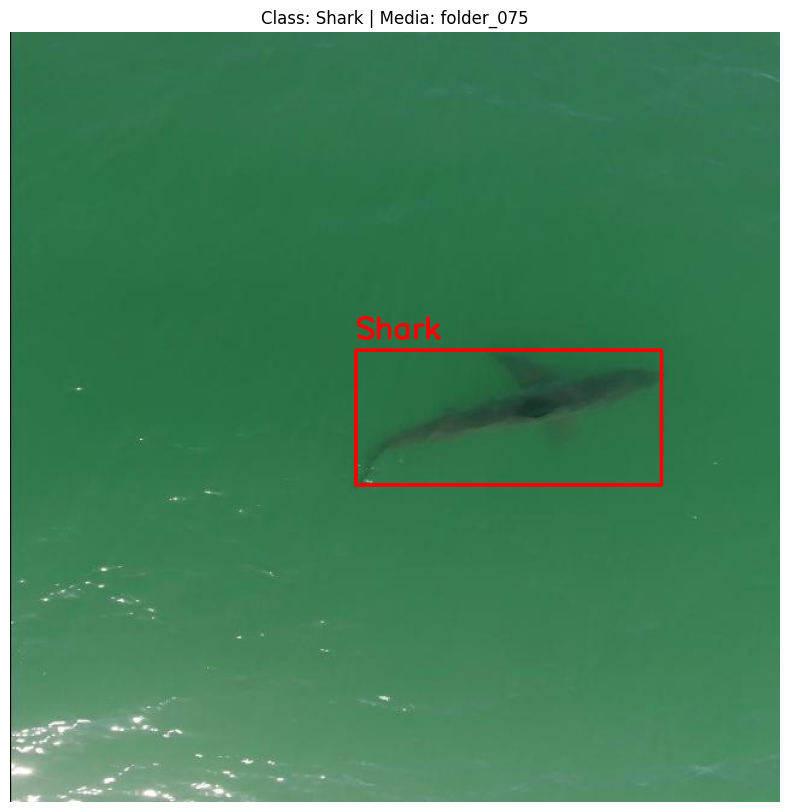

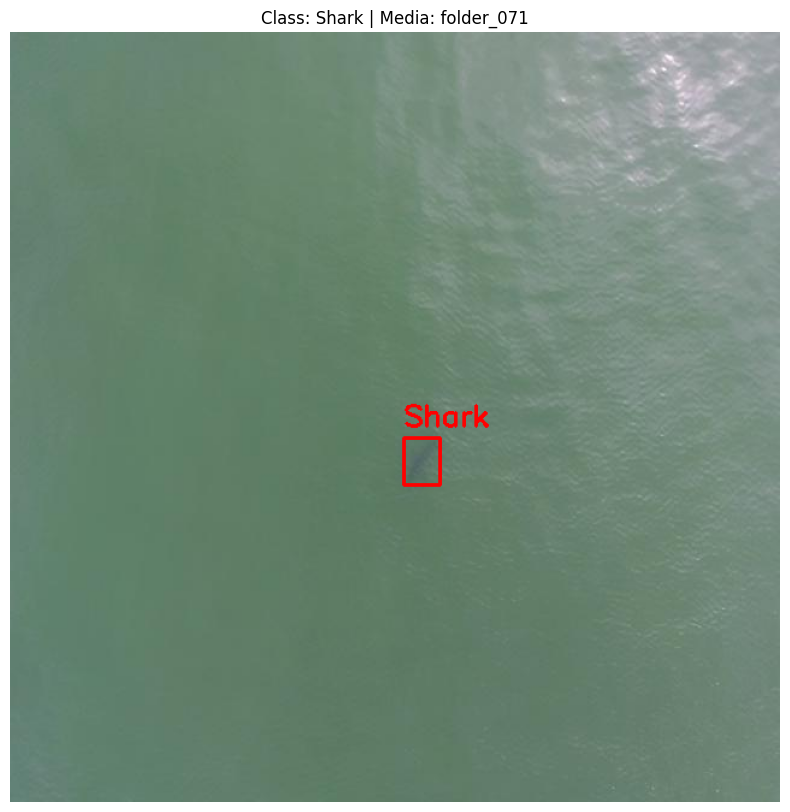

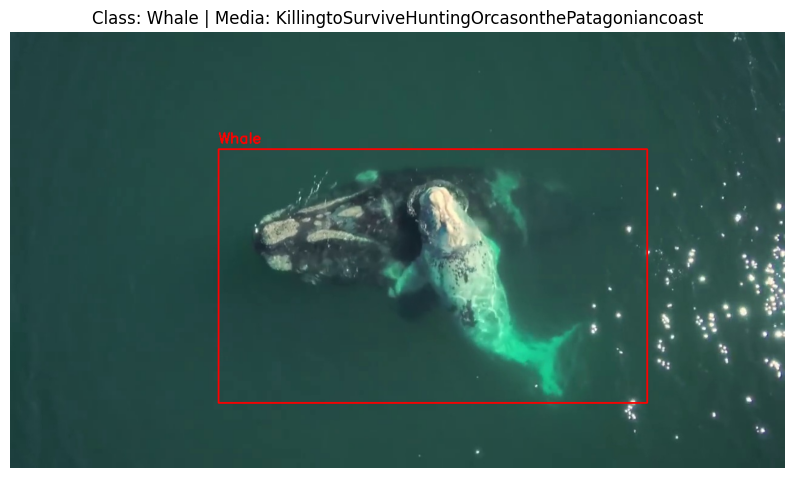

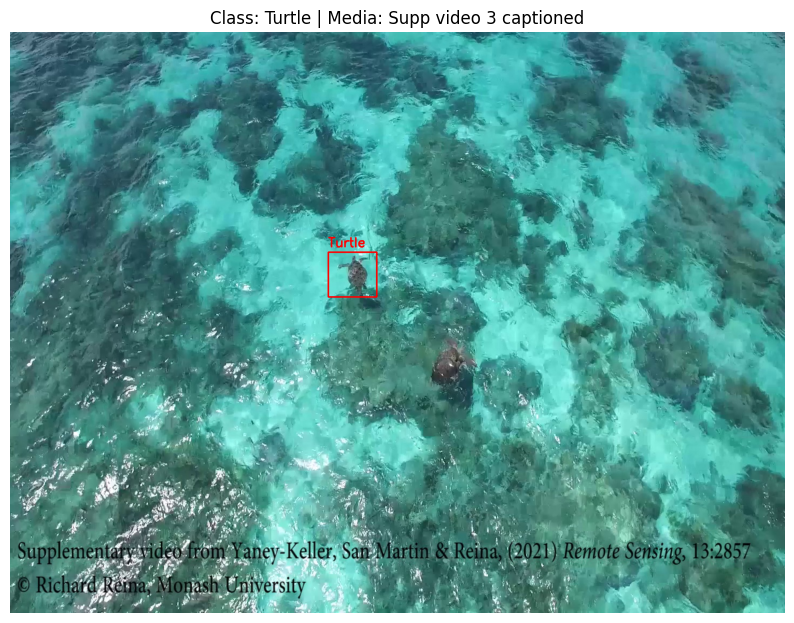

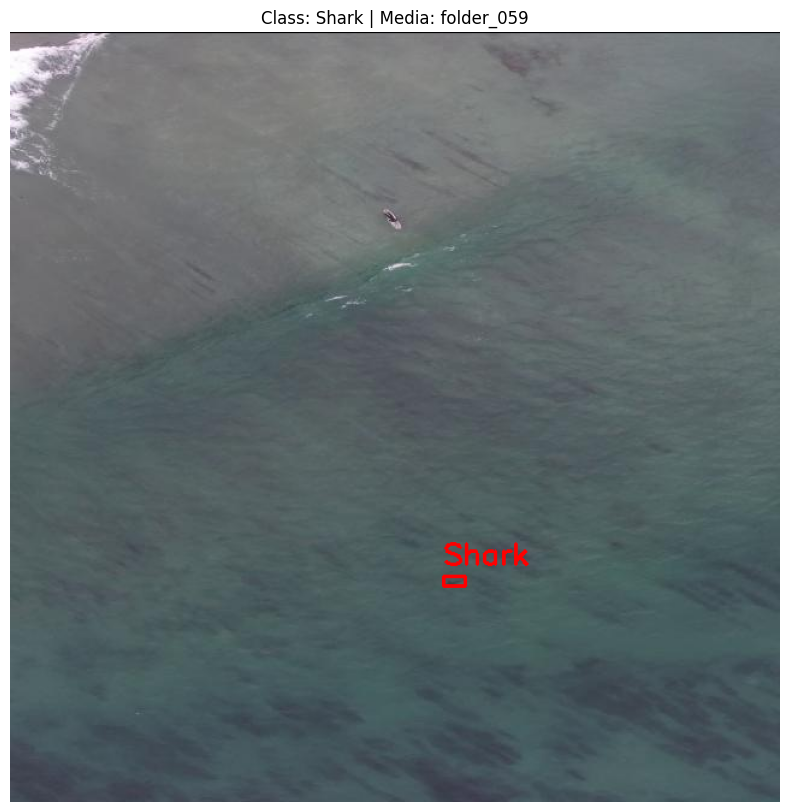

In [ ]:
# Visualización de muestras aleatorias

def show_random_samples(data, n=5):

    samples = random.sample(data, min(n, len(data)))

    for sample in samples:

        image_path = str(sample["image"])
        label_path = sample["label"]

        class_id = sample["class_id"]
        class_name = CLASS_NAMES[class_id]

        media_name = sample["media"]

        # Carga de imagen

        image = cv2.imread(image_path)

        if image is None:
            print(f"Could not load image: {image_path}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        # Carga de anotaciones

        with open(label_path, "r") as f:
            lines = f.readlines()

        # Se dibujan las cajas delimitadoras

        for line in lines:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            _, x, y, bw, bh = parts

            x_center = float(x) * w
            y_center = float(y) * h
            box_w = float(bw) * w
            box_h = float(bh) * h

            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                image,
                class_name,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),
                2
            )

        plt.figure(figsize=(10, 10))
        plt.imshow(image)

        plt.title(
            f"Class: {class_name} | Media: {media_name}"
        )

        plt.axis("off")
        plt.show()

# Visualización

show_random_samples(all_data, n=5)

# División y entrenamiento del modelo


In [ ]:

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not detected!")

OUTPUT = Path("/content/yolo_dataset_sequence_split")

# Creación de estructura YOLO

for folder in [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]:
    (OUTPUT / folder).mkdir(parents=True, exist_ok=True)

# Se dividen los subconjuntos de train/validation por secuencias

train_data = []
val_data = []

for class_id in DATASETS.keys():

    class_samples = [
        s for s in all_data
        if s["class_id"] == class_id
    ]

    # Se agrupan por secuencia o media

    media_groups = defaultdict(list)

    for sample in class_samples:
        media_groups[sample["media"]].append(sample)

    media_names = list(media_groups.keys())

    random.shuffle(media_names)

    # Se define una división 80/20

    split_idx = int(len(media_names) * 0.8)

    train_media = media_names[:split_idx]
    val_media = media_names[split_idx:]

    class_train = []

    for media in train_media:
        class_train.extend(media_groups[media])

    class_val = []

    for media in val_media:
        class_val.extend(media_groups[media])

    random.shuffle(class_train)
    random.shuffle(class_val)

    # Limitación del número de imágenes

    class_train = class_train[:400]
    class_val = class_val[:100]

    train_data.extend(class_train)
    val_data.extend(class_val)

    print(f"\nCLASS: {CLASS_NAMES[class_id]}")
    print(f"Train media: {len(train_media)}")
    print(f"Validation media: {len(val_media)}")
    print(f"Train images: {len(class_train)}")
    print(f"Validation images: {len(class_val)}")

print("\n================ FINAL SPLIT ================\n")

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Función de conversión de etiquetas

def convert_label_file(input_label, output_label, new_class_id):

    with open(input_label, "r") as f:
        lines = f.readlines()

    converted_lines = []

    for line in lines:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        _, x, y, w, h = parts

        converted_line = f"{new_class_id} {x} {y} {w} {h}\n"

        converted_lines.append(converted_line)

    with open(output_label, "w") as f:
        f.writelines(converted_lines)

# Función de preparación del split

def prepare_split(data, split):

    total = len(data)

    for idx, sample in enumerate(data):

        if idx % 25 == 0:
            print(f"{split}: {idx}/{total}")

        img_path = sample["image"]
        label_path = sample["label"]
        class_id = sample["class_id"]

        new_name = f"{split}_{idx}"

        out_img = OUTPUT / f"images/{split}/{new_name}{img_path.suffix}"
        out_label = OUTPUT / f"labels/{split}/{new_name}.txt"

        shutil.copy(img_path, out_img)

        convert_label_file(
            input_label=label_path,
            output_label=out_label,
            new_class_id=class_id
        )

# Se genera el dataset

prepare_split(train_data, "train")
prepare_split(val_data, "val")

print("\nDataset prepared.")

# Archivo data.yaml

yaml_text = f"""
path: {OUTPUT}

train: images/train
val: images/val

names:
  0: Turtle
  1: Whale
  2: Shark
"""

with open("/content/data_sequence.yaml", "w") as f:
    f.write(yaml_text)

print("data_sequence.yaml created.")

# Se carga el modelo YOLOv8

model = YOLO("yolov8s.pt")

# Posteriormente, se entrena el modelo

model.train(
    data="/content/data_sequence.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,

    project="/content/drive/MyDrive/TFM_DELT/runs",
    name="sequence_split_experiment"
)

# El mejor modelo queda guardado en best.pt

print("\nTraining finished.")
print("Best model saved in:")

print(
    "/content/drive/MyDrive/TFM_DELT/runs/"
    "sequence_split_experiment/weights/best.pt"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4

CLASS: Turtle
Train media: 30
Validation media: 8
Train images: 400
Validation images: 100

CLASS: Whale
Train media: 17
Validation media: 5
Train images: 400
Validation images: 100

CLASS: Shark
Train media: 68
Validation media: 18
Train images: 400
Validation images: 100

================ FINAL SPLIT ================

Train samples: 1200
Validation samples: 300
train: 0/1200
train: 25/1200
train: 50/1200
train: 75/1200
train: 100/1200
train: 125/1200
train: 150/1200
train: 175/1200
train: 200/1200
train: 225/1200
train: 250/1200
train: 275/1200
train: 300/1200
train: 325/1200
train: 350/1200
train: 375/1200
train: 400/1200
train: 425/1200
trai

# Evaluación del modelo

In [ ]:
# Carga del modelo entrenado y guardado en best.pt

MODEL_PATH = "/content/drive/MyDrive/TFM_DELT/runs/sequence_split_experiment/weights/best.pt"

model = YOLO(MODEL_PATH)

# Validación del modelo

DATA_YAML = "/content/data_sequence.yaml"

metrics = model.val(
    data=DATA_YAML,
    split="val",
    conf=0.25,
    iou=0.5,
    project="/content/drive/MyDrive/TFM_DELT/runs",
    name="final_evaluation"
)

########## Métricas globales

print("\n================ GLOBAL METRICS ================\n")

print(f"mAP@0.5:        {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:   {metrics.box.map:.4f}")
print(f"Precision:      {metrics.box.mp:.4f}")
print(f"Recall:         {metrics.box.mr:.4f}")

# Cálculo del F1-score

precision = metrics.box.mp
recall = metrics.box.mr

f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

print(f"F1 Score:       {f1:.4f}")

########## Métricas por clase

print("\n================ PER-CLASS METRICS ================\n")

results_table = []

for i, class_name in CLASS_NAMES.items():

    class_map50 = metrics.box.ap50[i]
    class_map95 = metrics.box.ap[i]

    results_table.append({
        "Class": class_name,
        "mAP50": round(float(class_map50), 4),
        "mAP50-95": round(float(class_map95), 4)
    })

df = pd.DataFrame(results_table)

print(df)

# Se visualizan predicciones

VAL_IMAGES_DIR = Path("/content/yolo_dataset_sequence_split/images/val")

val_images = (
    list(VAL_IMAGES_DIR.glob("*.jpg")) +
    list(VAL_IMAGES_DIR.glob("*.jpeg")) +
    list(VAL_IMAGES_DIR.glob("*.png"))
)

samples = random.sample(val_images, min(5, len(val_images)))

for image_path in samples:

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        verbose=False
    )

    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load: {image_path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Se dibujan predicciones

    for result in results:

        for box in result.boxes:

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            conf = float(box.conf[0])

            cls = int(box.cls[0])

            label = f"{CLASS_NAMES[cls]} {conf:.2f}"

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            cv2.putText(
                image,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

# Rendimiento de detección por clase

In [ ]:
CLASS_NAMES = {
    0: "Turtle",
    1: "Whale",
    2: "Shark"
}

# Se genera la matriz de confusión

cm = metrics.confusion_matrix.matrix

results = []

# Se calculan las métricas por clase

for i, class_name in CLASS_NAMES.items():

    # Verdaderos positivos
    tp = cm[i, i]

    # Falsos negativos
    fn = cm[i, -1]

    # Total de objetos reales
    total_gt = tp + fn

    # Porcentaje de detección
    detection_percentage = (
        tp / total_gt * 100
        if total_gt > 0 else 0
    )

    results.append({
        "Class": class_name,
        "Correct Detections": int(tp),
        "Missed Detections": int(fn),
        "Total GT Objects": int(total_gt),
        "Detection %": round(detection_percentage, 2)
    })

# Y se genera una tabla de resultados

df = pd.DataFrame(results)

print("\n========== PER-CLASS DETECTION PERFORMANCE ==========\n")

print(df)


========== PER-CLASS DETECTION PERFORMANCE ==========

    Class  Correct Detections  Missed Detections  Total GT Objects  \
0  Turtle                  97                 12               109   
1   Whale                  92                 31               123   
2   Shark                 106                 22               128   

   Detection %  
0        88.99  
1        74.80  
2        82.81  
